In [134]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import pickle
from tqdm import tqdm

from src.mps_utils import to_comp_basis

## Helper functions

In [3]:
def get_all_failed_runs():
    qpd6_result_folders = []
    for folder in os.listdir("data"):
        if folder.startswith("qpd6_new_solver_test"):
            qpd6_result_folders.append(folder)

    all_failed_runs = []
    for folder in qpd6_result_folders:
        for subdir in os.listdir(os.path.join("data", folder)):
            for gradient_method in ["ols_noridge", "ols_ridge0.01"]:
                try:
                    failed_runs = os.listdir(os.path.join("data", folder, subdir, gradient_method, 'failed_runs'))
                    all_failed_runs.extend(
                        [os.path.join("data", folder, subdir, gradient_method, 'failed_runs', fn) for fn in failed_runs]
                    )
                except FileNotFoundError:
                    print(f"No failed runs found for {folder} {subdir} {gradient_method}")
                    pass
    return all_failed_runs

all_failed_runs = get_all_failed_runs()


No failed runs found for qpd6_new_solver_test chi_16 ols_noridge
No failed runs found for qpd6_new_solver_test chi_16 ols_ridge0.01
No failed runs found for qpd6_new_solver_test chi_4 ols_noridge
No failed runs found for qpd6_new_solver_test chi_4 ols_ridge0.01
No failed runs found for qpd6_new_solver_test chi_8 ols_noridge
No failed runs found for qpd6_new_solver_test chi_8 ols_ridge0.01
No failed runs found for qpd6_new_solver_test chi_2 ols_noridge
No failed runs found for qpd6_new_solver_test chi_2 ols_ridge0.01
No failed runs found for qpd6_new_solver_test chi_6 ols_noridge
No failed runs found for qpd6_new_solver_test chi_6 ols_ridge0.01
No failed runs found for qpd6_new_solver_test_newdtype-explmaxiter200 chi_8 ols_noridge
No failed runs found for qpd6_new_solver_test_newdtype-explmaxiter200 chi_8 ols_ridge0.01
No failed runs found for qpd6_new_solver_test_newdtype-explmaxiter200 chi_2 ols_noridge
No failed runs found for qpd6_new_solver_test_newdtype-explmaxiter200 chi_2 ols_ri

In [4]:
success_count = 0
all_failed_results = []
for failed_result_path in tqdm(all_failed_runs):
    failed_result = pickle.load(open(failed_result_path, "rb"))
    all_failed_results.append(failed_result)

import datetime 
pickle.dump(all_failed_results, open(f"data/debug/all_failed_results_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.pkl", "wb"))


100%|██████████| 333/333 [00:15<00:00, 21.77it/s]


## Analysis

In [5]:
all_failed_results = pickle.load(open("data/debug/all_failed_results_20260112_145740.pkl", "rb"))


In [6]:
state = to_comp_basis(all_failed_results[10]['current_state'])
init_state = all_failed_results[10]['problematic_result']['state'][-1].reshape(2**6)

In [7]:
init_state - state

array([ 0., -0., -0.,  0., -0.,  0., -0.,  0., -0., -0.,  0.,  0.,  0.,
       -0.,  0., -0., -0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0.,
        0.,  0.,  0.,  0., -0., -0., -0.,  0., -0.,  0.,  0.,  0., -0.,
       -0., -0.,  0.,  0., -0.,  0., -0., -0., -0.,  0., -0., -0., -0.,
       -0.,  0.,  0., -0., -0.,  0., -0.,  0.,  0.,  0.,  0., -0.])

In [29]:
states[-1].reshape(2**6)
from src.solver import find_nash_eq1
from src.game import get_default_cyclic_players
from copy import deepcopy

result = failed_run_results[1]
states = result['problematic_result']['state']
states_mps = result['problematic_result']['state_']
a = deepcopy(states_mps[0])

H = get_default_cyclic_players(6)

result = find_nash_eq1(
    a,
    H,
    max_iter=1000,
    alpha=0.4,
    convergence_threshold=1e-7,
    expl_threshold=1e-7,
    use_tqdm=True,
    expl_check_interval=50,
    return_history=True,
    real_strategies=True,
)

  0%|          | 0/1000 [00:00<?, ?it/s]

 20%|██        | 200/1000 [00:00<00:03, 251.09it/s]


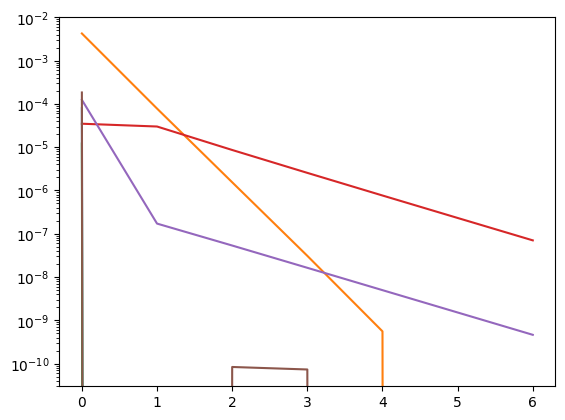

In [28]:
plt.plot(result['expl'])
plt.yscale('log')

## Failed runs Hamiltonian sweeps

In [8]:
data_folder_path = "data/hamiltonian_sweep_3p_complex_v1/hseed_1000"
trail_data_path = "/mnt/users/clin/workspace/nash/data/hamiltonian_sweep_3p_complex_v1/hseed_1000/noncomm_0.2/qpd3_20260112_173250_68349127.pkl"

import pickle
df = pickle.load(open(trail_data_path, "rb"))
print(df.keys())


dict_keys(['metadata', 'metric_logs', 'dataframe', 'Hamiltonian', 'failed_runs', 'failed_run_metadata'])


In [9]:
from src.solver import find_nash_eq1, find_nash_eq1_with_retry

df_failed = df['failed_runs']
df_failed = pd.DataFrame(df_failed)
print(df['failed_run_metadata'])

{'subroutine_max_iter': 1000, 'max_failures_before_abort': 20, 'expl_check_interval': 50, 'expl_threshold': 1e-07, 'expl_maxiter': 200, 'real_strategies': False, 'max_subroutine_lr': 0.6, 'min_subroutine_lr': 0.001}


100%|██████████| 1000/1000 [00:03<00:00, 332.03it/s]


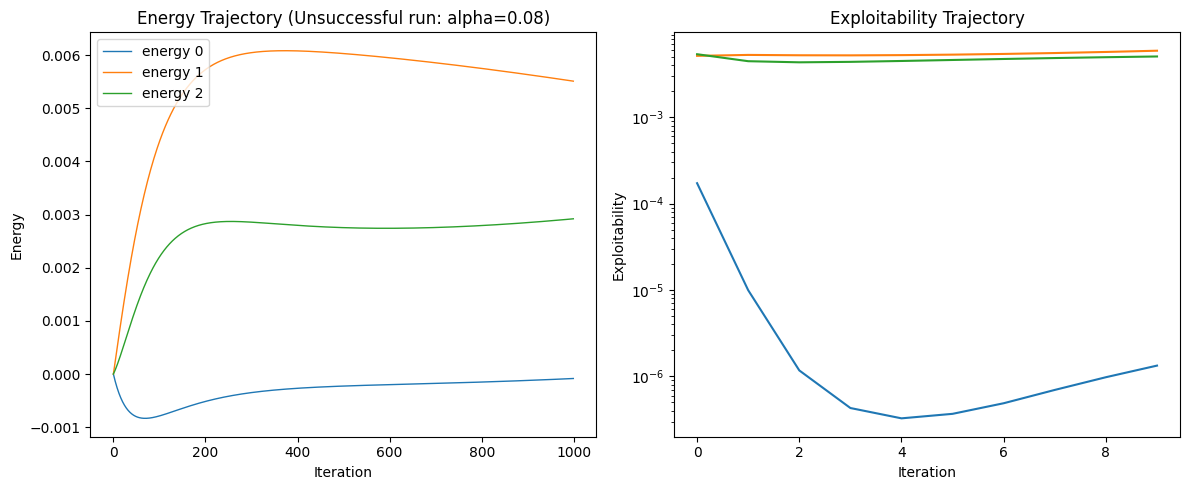

In [138]:
idx = 6
from copy import deepcopy
state = deepcopy(df_failed['state'].iloc[idx])
metadata = df['failed_run_metadata']
H = df['Hamiltonian']
result = find_nash_eq1(state, df['Hamiltonian'], max_iter=1000, alpha=0.07, expl_check_interval=100, expl_maxiter=100, real_strategies=metadata['real_strategies'], return_history=True, use_tqdm=True)
plot_energy_and_exploitability(result)
# result, success, current_alpha = find_nash_eq1_with_retry(
#     state, H,
#     max_iter=metadata["subroutine_max_iter"],
#     base_alpha=df_failed['base_alpha'].iloc[idx],
#     max_alpha=metadata['max_subroutine_lr'],
#     expl_check_interval=metadata['expl_check_interval'],
#     real_strategies=metadata['real_strategies'],
#     max_retries=metadata['max_failures_before_abort'],
#     expl_maxiter=metadata['expl_maxiter'],
#     expl_threshold=metadata['expl_threshold'],
#     min_alpha=metadata['min_subroutine_lr'],
#     return_history=True,
# )

In [137]:
from src.mps_utils import apply_random_unitaries

state_ = apply_random_unitaries(state, epsilon=0)

result = find_nash_eq1(state, df['Hamiltonian'], max_iter=1000, alpha=0.4, expl_check_interval=metadata['expl_check_interval'], expl_maxiter=metadata['expl_maxiter'], real_strategies=metadata['real_strategies'], return_history=True, use_tqdm=True, convergence_threshold=1e-10)

  0%|          | 0/1000 [00:00<?, ?it/s]


IndexError: tuple index out of range

In [112]:
from utils.misc import plot_energy_and_exploitability
def plot_energy_and_exploitability(result, relative_to_init=True):
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Left panel: Energy
    if relative_to_init:
        axs[0].plot(result['energy']-result['energy'][0], linewidth=1, label=[f"energy {i}" for i in range(len(result['energy'][0]))])
    else:
        axs[0].plot(result['energy'], linewidth=1, label=[f"energy {i}" for i in range(len(result['energy'][0]))])
    axs[0].set_xlabel("Iteration")
    axs[0].set_ylabel("Energy")
    axs[0].set_title("Energy Trajectory (Unsuccessful run: alpha=0.08)")
    axs[0].legend()

    # Right panel: Exploitability
    axs[1].plot(result['expl'])
    axs[1].legend()
    axs[1].set_xlabel("Iteration")
    axs[1].set_ylabel("Exploitability")
    axs[1].set_title("Exploitability Trajectory")
    axs[1].set_yscale('log')

    plt.tight_layout()


In [65]:
result['state'][-1].reshape([2]*3)

array([[[ 0.196+0.002j, -0.224+0.126j],
        [-0.177-0.254j, -0.252-0.265j]],

       [[ 0.159+0.192j,  0.247+0.204j],
        [-0.28 +0.211j,  0.516-0.335j]]])

In [64]:
to_comp_basis(state)

array([ 0.196+0.002j, -0.224+0.126j, -0.177-0.254j, -0.252-0.265j,
        0.159+0.192j,  0.247+0.204j, -0.28 +0.211j,  0.516-0.335j])

In [79]:
from src.solver import compute_exploitability
import time

t0 = time.time()
for _ in tqdm(range(100)):
    for i in range(3):
        compute_exploitability(result['state'][-1], H, player_idx=i, real_strategies=False)
t1 = time.time()
print(t1-t0)

100%|██████████| 100/100 [00:29<00:00,  3.37it/s]

29.63595747947693


In [12]:
from src.solver import update_state_unitary
from src.mps_utils import to_comp_basis, get_product_state

state = get_product_state(L=4, state_per_site=np.array([0, 0, 0, 1]), dtype=np.complex128)
def print_bond_dims(state: list[np.ndarray]):
    chis = []
    for i in range(len(state)):
        chis.append(state[i].shape[2])
    chis.pop()
    print(chis)

new_state = update_state_unitary(state, np.array([1,2,3,4,5,6,7,8,9]), lr=0.01, site=0)
new_state = update_state_unitary(new_state, np.array([1,2,3,4,5,6,7,8,9]), lr=0.01, site=1)
new_state = update_state_unitary(new_state, np.array([1,2,3,4,5,6,7,8,9]), lr=0.01, site=2)
new_state = update_state_unitary(new_state, np.array([1,2,3,4,5,6,7,8,9]), lr=0.01, site=1)

  Clipping gradient: 16.8819 → 1.0000
  Clipping gradient: 16.8819 → 1.0000
  Clipping gradient: 16.8819 → 1.0000
  Clipping gradient: 16.8819 → 1.0000


  Clipping gradient: 2.5334 → 1.0000
[array([[[-1.   -0.005j,  0.   +0.j   ]],

       [[ 0.004-0.002j,  0.004+0.002j]]]), array([[[-0.639+0.769j, -0.013+0.001j, -0.   -0.j   , -0.   +0.j   ],
        [-0.013+0.004j, -0.002+0.007j,  0.   +0.j   , -0.   -0.j   ]],

       [[ 0.001-0.014j, -0.003-0.008j,  0.   +0.j   , -0.   +0.j   ],
        [-0.622+0.783j,  0.013-0.001j,  0.   +0.j   ,  0.   -0.j   ]]]), array([[[-0.663-0.j   ,  0.472+0.581j],
        [-0.003+0.005j,  0.   -0.001j],
        [-0.247-0.182j, -0.016-0.274j],
        [ 0.665+0.156j,  0.262+0.543j]],

       [[-0.005+0.002j,  0.001+0.j   ],
        [ 0.038-0.661j, -0.6  +0.45j ],
        [-0.608+0.313j, -0.556-0.23j ],
        [-0.196+0.236j, -0.275+0.j   ]]]), array([[[-0.749+0.j   ],
        [-0.424+0.509j]],

       [[ 0.424+0.509j],
        [-0.749-0.j   ]]])]


100%|██████████| 1000/1000 [00:07<00:00, 141.65it/s]
/tmp/ipykernel_4001156/895188333.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()


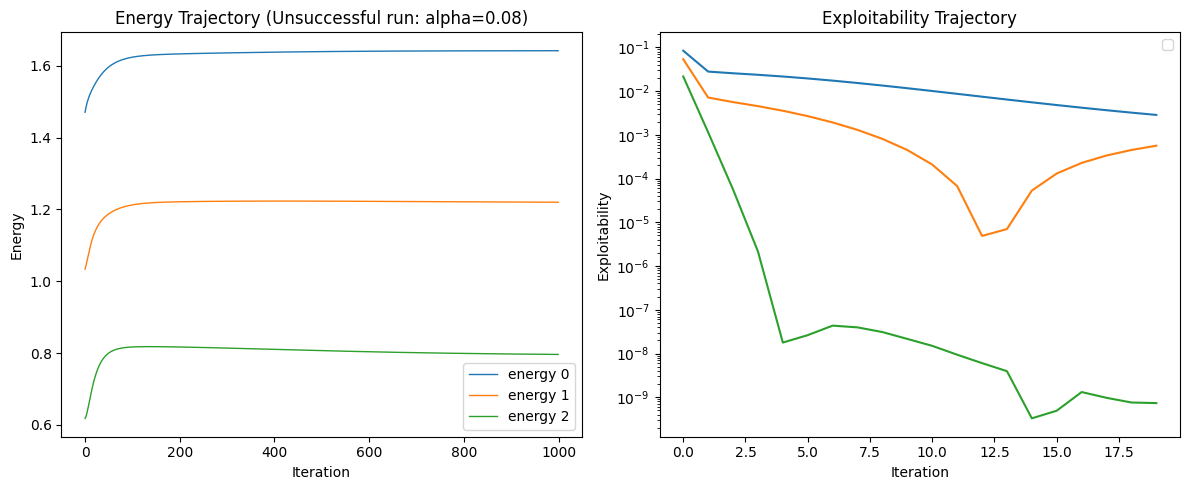

In [155]:
def scramble(state, depth=10, unitary_eps=0.1, seed=42):
    L = len(state)
    np.random.seed(seed)
    for i in range(depth):
        state = update_state_unitary(state, np.random.randn(9), lr=unitary_eps, site=np.mod(i, L-1))
    return state

new_state_ = scramble(get_product_state(L=3, state_per_site=[1, 1, 1], dtype=np.complex128), depth=1, unitary_eps=0.1)
print(new_state)
H = df['Hamiltonian']
from src.game import get_default_cyclic_players
result = find_nash_eq1(new_state_, H, max_iter=1000, alpha=0.1, expl_check_interval=50, expl_maxiter=100, real_strategies=False, return_history=True, use_tqdm=True, expl_threshold=1e-6)
plot_energy_and_exploitability(result, relative_to_init=False)

100%|██████████| 1000/1000 [00:03<00:00, 291.33it/s]


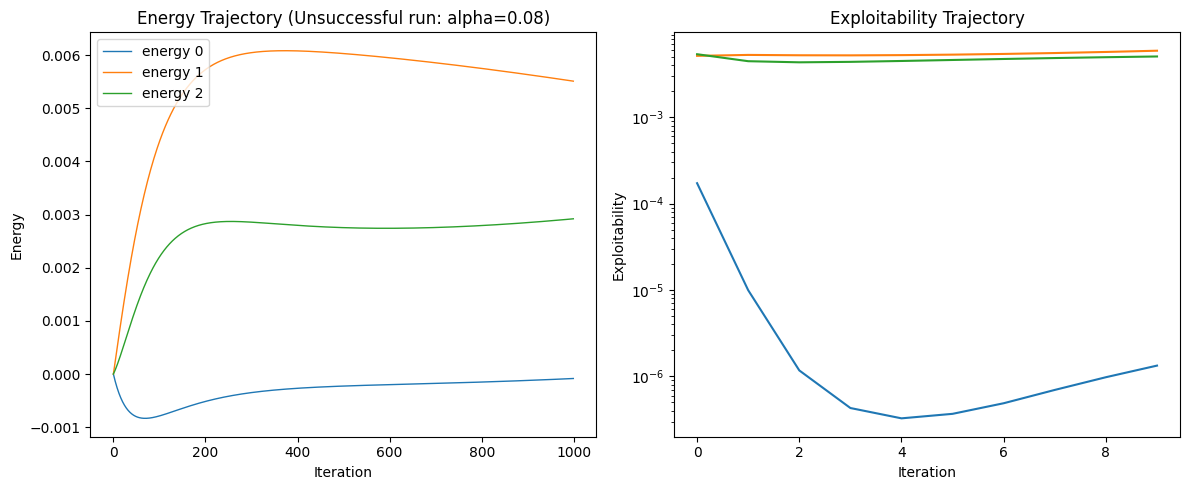

### Aside: 3-qubit scrambling dynamics...

  Clipping gradient: 2.5334 → 1.0000
  Clipping gradient: 2.9768 → 1.0000


100%|██████████| 1000/1000 [00:06<00:00, 153.52it/s]
/tmp/ipykernel_4001156/895188333.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()


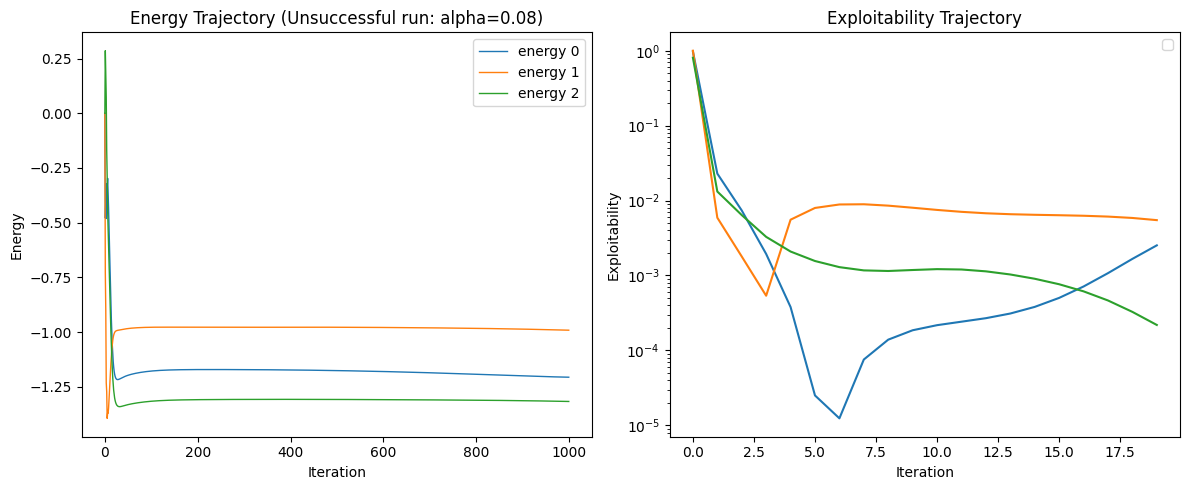

In [167]:
from src.game import get_perturbed_H_QPD
from src.mps_utils import get_rand_mps
psi = get_product_state(L=3, state_per_site=[1, 1, 1], dtype=np.complex128)
psi = scramble(psi, depth=2, unitary_eps=0.01)
psi = get_rand_mps(L=3, chi=2, dtype=np.complex128)

hamiltonian_seed = 1002
Hs = get_perturbed_H_QPD(eps=0.2, dtype=np.complex128, seed=hamiltonian_seed)
H = get_default_cyclic_players(L=3, Hs=Hs)

baseline_result = find_nash_eq1(psi, H, max_iter=1000, alpha=0.4, expl_check_interval=50, expl_maxiter=100, real_strategies=False, return_history=True, use_tqdm=True, expl_threshold=1e-10, convergence_threshold=1e-7)
plot_energy_and_exploitability(baseline_result, relative_to_init=True)

# No Nash states are formed in this case, meaning that the unitaries combined makes the energy stationary, but when viewd from each individual player, the motivation to apply such unitaries is still present. This would explain 1. the energy trajectory is stationary, 2. No Nash states are reported, 3. The exploitability is still high.

  Clipping gradient: 2.6661 → 1.0000


100%|██████████| 300/300 [00:02<00:00, 144.64it/s]
/tmp/ipykernel_4001156/895188333.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()


Converged to Nash state at iteration 267


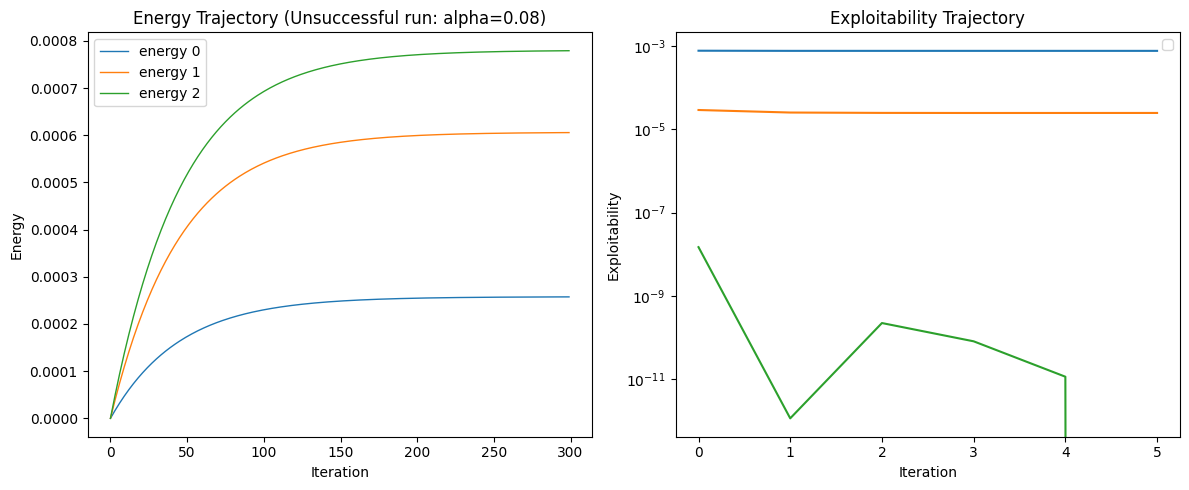

In [153]:
psi = scramble(baseline_result['state_'][-1], depth=1, unitary_eps=0.01)
perturbed_result = find_nash_eq1(psi, H, max_iter=300, alpha=0.04, expl_check_interval=50, expl_maxiter=100, real_strategies=False, return_history=True, use_tqdm=True, expl_threshold=1e-6)
plot_energy_and_exploitability(perturbed_result, relative_to_init=True)

## The special run

dict_keys(['metadata', 'metric_logs', 'dataframe', 'Hamiltonian'])


 17%|█▋        | 501/3000 [00:01<00:07, 326.56it/s]

Converged to Nash state at iteration 574


 20%|██        | 600/3000 [00:02<00:08, 286.97it/s]
/tmp/ipykernel_4001156/895188333.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()


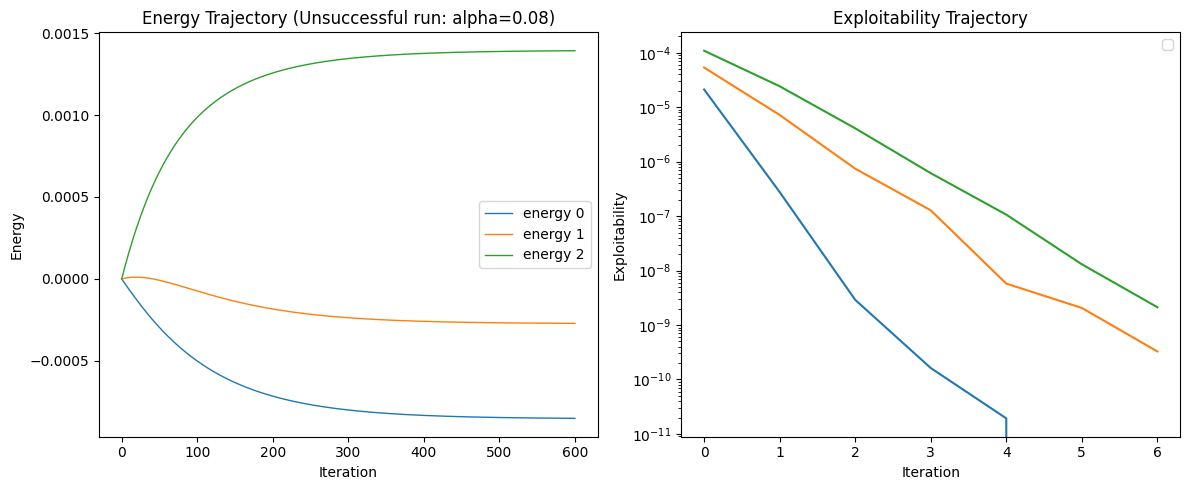

In [149]:
data_path = "data/qpd_3player_nocomm/qpd3_20260103_122051_06c94f4a.pkl"
df = pickle.load(open(data_path, "rb"))
print(df.keys())

metric_logs = pd.DataFrame(df['metric_logs'])
metric_logs.head()

trail_state = metric_logs['state'].iloc[230]

outcome = find_nash_eq1(trail_state, df['Hamiltonian'], max_iter=3000, alpha=0.5, expl_check_interval=100, expl_maxiter=100, real_strategies=False, return_history=True, use_tqdm=True, expl_threshold=1e-8)
plot_energy_and_exploitability(outcome, relative_to_init=True)